<a href="https://colab.research.google.com/github/vainqueuritunime/PR-DICTION-DE-L-OCTROI-DE-CR-DIT/blob/main/Octroi_du_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRÉDICTION DE L'OCTROI DE CRÉDIT

# **Objectif :** Prédire si un client ou une cliente a la possibilité d'obtenir un prêt auprès d'une banque en fonction de son profil.

**Importation des dépendances**

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [209]:
# Lecture des données avec pandas
df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

# Convertir 'loan_status' en valeurs numériques (1 pour Approuvé, 0 pour Rejeté)
df['loan_status'] = df['loan_status'].str.strip().map({'Approved': 1, 'Rejected': 0})

In [210]:
print("Les 5 premières lignes de notre DataFrame :")
df.head()

Les 5 premières lignes de notre DataFrame :


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [211]:
print("Les 5 dernières lignes de notre DataFrame :")
df.tail()

Les 5 dernières lignes de notre DataFrame :


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,1


In [212]:
print("Nombre de lignes et de colonnes de notre DataFrame :")
print(f"Notre DataFrame contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Nombre de lignes et de colonnes de notre DataFrame :
Notre DataFrame contient 4269 lignes et 13 colonnes.


In [213]:
print("Affichage de tous les noms de colonnes :")
# Récupérons les données
# Parcourons les données
# Et affichons-les
colonnes = df.columns
for noms_colonnes in colonnes:
  print(noms_colonnes)

Affichage de tous les noms de colonnes :
loan_id
no_of_dependents
education
self_employed
income_annum
loan_amount
loan_term
cibil_score
residential_assets_value
commercial_assets_value
luxury_assets_value
bank_asset_value
loan_status


In [214]:
# loan_id : Identifiant unique du dossier de prêt.
# no_of_dependents : Nombre de personnes à charge (enfants ou famille) qui dépendent financièrement du demandeur.
# education : Niveau d'études du demandeur (par exemple : diplômé ou non-diplômé).
# self_employed : Indépendant ou travailleur autonome (Oui ou Non).
# income_annum : Revenu annuel du demandeur.
# loan_amount : Montant total du prêt demandé.
# loan_term : Durée du prêt (en années)
# cibil_score : Score de crédit (une note de 300 à 900 qui indique la fiabilité financière de la personne).
# residential_assets_value : Valeur des biens immobiliers d'habitation (maison, appartement).
# commercial_assets_value : Valeur des biens immobiliers commerciaux (magasins, bureaux).
# luxury_assets_value : Valeur des biens de luxe (voitures haut de gamme, bijoux, etc.).
# bank_asset_value : Valeur des avoirs et comptes en banque.
# loan_status : Statut final du prêt (la cible à prédire : accordé ou rejeté).

In [215]:
print("Statistiques descriptives :")
df.describe()

Statistiques descriptives :


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [216]:
print("Valeurs manquantes :")
valeurs_manquantes = df.isnull().sum()
valeurs_manquantes

Valeurs manquantes :


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [217]:
print("Suppression des doublons :")
doublons = df.drop_duplicates()
doublons.head()

Suppression des doublons :


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [218]:
print("Nombre de rejets et de prêts acceptés :")
df['loan_status'].value_counts()

Nombre de rejets et de prêts acceptés :


,count
loan_status,
1,2656
0,1613


In [219]:
# Cette cellule a été déplacée plus haut pour assurer la conversion de 'loan_status' en numérique plus tôt.

## **ANALYSE DES DONNÉES**

In [220]:
## Les niveaux d'études ont-ils une relation avec la cible ?
# Récupérer les niveaux
# Et effectuer une agrégation
niveau_etude = df.groupby('education', as_index=False)['loan_status'].mean()
niveau_etude

,education,loan_status
0,Graduate,0.624534
1,Not Graduate,0.619765


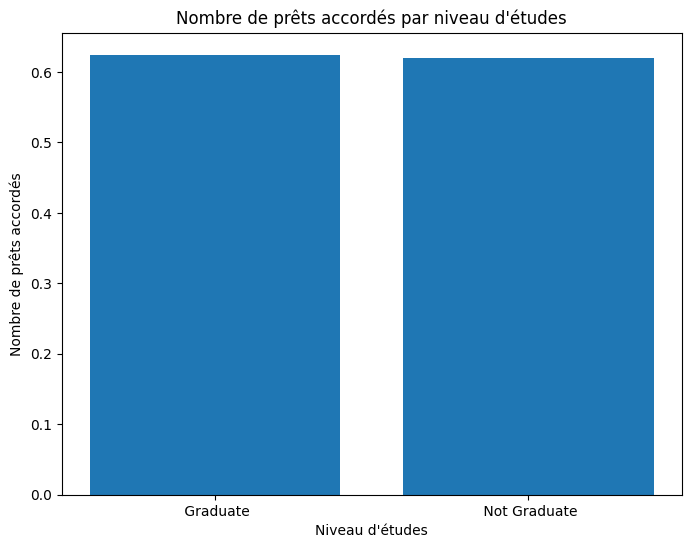

In [221]:
plt.figure(figsize=(8,6))
plt.bar(x=niveau_etude['education'], height=niveau_etude['loan_status'])
plt.title("Nombre de prêts accordés par niveau d'études")
plt.xlabel("Niveau d'études")
plt.ylabel("Nombre de prêts accordés")
plt.show()

In [222]:
print("Nombre d'indépendants ou de travailleurs autonomes :")
indépendant = df['self_employed'].value_counts()
indépendant

Nombre d'indépendants ou de travailleurs autonomes :


,count
self_employed,
Yes,2150
No,2119


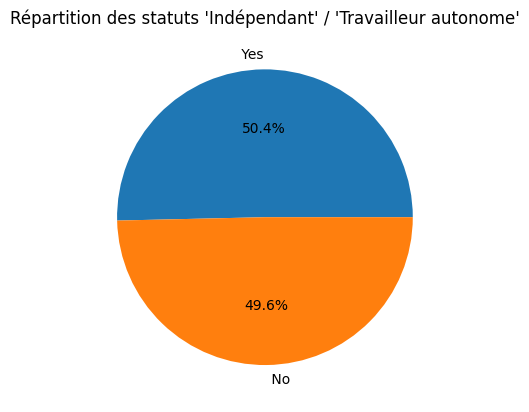

In [223]:
plt.pie(indépendant, labels=indépendant.index, autopct='%1.1f%%')
plt.title("Répartition des statuts 'Indépendant' / 'Travailleur autonome'")
plt.show()

Relation entre le revenu annuel du demandeur et le montant total du prêt demandé :


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

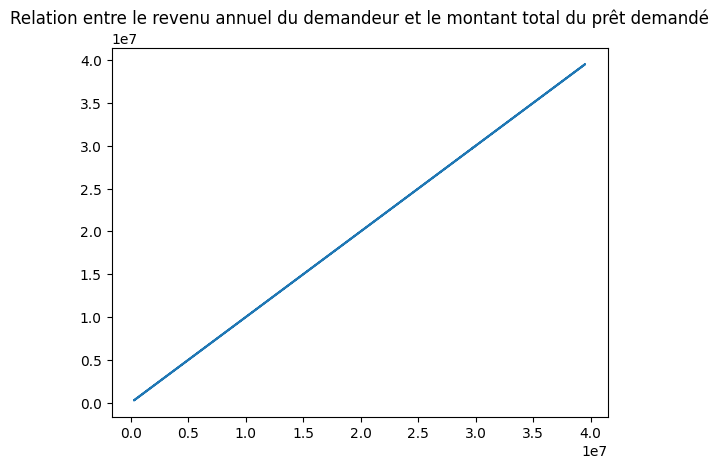

In [224]:
print("Relation entre le revenu annuel du demandeur et le montant total du prêt demandé :")
plt.plot(df['loan_amount'], df['loan_amount'])
plt.title("Relation entre le revenu annuel du demandeur et le montant total du prêt demandé")
plt

In [225]:
# Importer les outils nécessaires
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [226]:
cible = df['loan_status']
features = df.drop(columns='loan_status', axis=1)
x = features
y = cible

### Préparation des données pour le modèle

In [227]:
# Application de l'encodage One-Hot aux variables catégorielles
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

print("Aperçu des caractéristiques après encodage :")
print(x_encoded.head())

Aperçu des caractéristiques après encodage :
   loan_id  no_of_dependents  income_annum  loan_amount  loan_term  \
0        1                 2       9600000     29900000         12   
1        2                 0       4100000     12200000          8   
2        3                 3       9100000     29700000         20   
3        4                 3       8200000     30700000          8   
4        5                 5       9800000     24200000         20   

   cibil_score  residential_assets_value  commercial_assets_value  \
0          778                   2400000                 17600000   
1          417                   2700000                  2200000   
2          506                   7100000                  4500000   
3          467                  18200000                  3300000   
4          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  education_ Not Graduate  \
0             22700000           8000000          

In [228]:
# Division des données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")
print(f"Taille de l'ensemble d'entraînement (y_train): {y_train.shape}")
print(f"Taille de l'ensemble de test (y_test): {y_test.shape}")

Taille de l'ensemble d'entraînement (X_train): (3415, 12)
Taille de l'ensemble de test (X_test): (854, 12)
Taille de l'ensemble d'entraînement (y_train): (3415,)
Taille de l'ensemble de test (y_test): (854,)


### Entraînement et évaluation du modèle

### Préparation des données pour le modèle

In [229]:
# Application de l'encodage One-Hot aux variables catégorielles
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

print("Aperçu des caractéristiques après encodage :")
print(x_encoded.head())

Aperçu des caractéristiques après encodage :
   loan_id  no_of_dependents  income_annum  loan_amount  loan_term  \
0        1                 2       9600000     29900000         12   
1        2                 0       4100000     12200000          8   
2        3                 3       9100000     29700000         20   
3        4                 3       8200000     30700000          8   
4        5                 5       9800000     24200000         20   

   cibil_score  residential_assets_value  commercial_assets_value  \
0          778                   2400000                 17600000   
1          417                   2700000                  2200000   
2          506                   7100000                  4500000   
3          467                  18200000                  3300000   
4          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  education_ Not Graduate  \
0             22700000           8000000          

In [230]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")
print(f"Taille de l'ensemble d'entraînement (y_train): {y_train.shape}")
print(f"Taille de l'ensemble de test (y_test): {y_test.shape}")

Taille de l'ensemble d'entraînement (X_train): (3415, 12)
Taille de l'ensemble de test (X_test): (854, 12)
Taille de l'ensemble d'entraînement (y_train): (3415,)
Taille de l'ensemble de test (y_test): (854,)


### Entraînement et évaluation du modèle

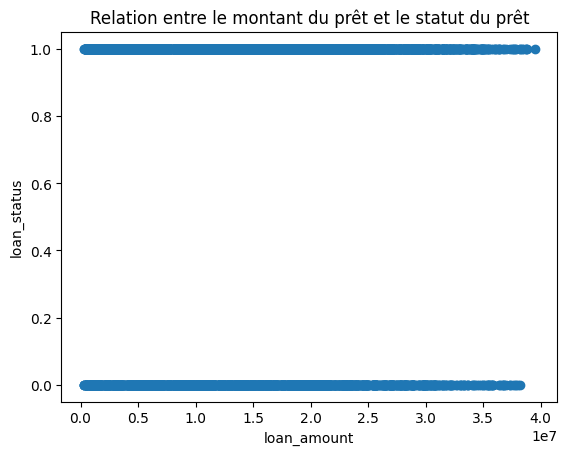

In [231]:
plt.figure()
plt.scatter(x['loan_amount'], y)
plt.xlabel('loan_amount')
plt.ylabel('loan_status')
plt.title('Relation entre le montant du prêt et le statut du prêt')
plt.show()

In [232]:
# Importation du modèle et des métriques
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [233]:
# Initialisation et entraînement du modèle de régression logistique
model = LogisticRegression(max_iter=1000, random_state=42) # Augmenter max_iter pour convergence si nécessaire
model.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


In [234]:
# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle sur l'ensemble de test : {accuracy:.2f}")

Précision du modèle sur l'ensemble de test : 0.82


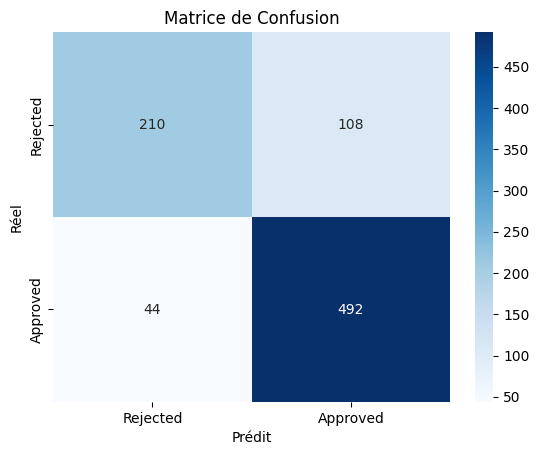


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.83      0.66      0.73       318
           1       0.82      0.92      0.87       536

    accuracy                           0.82       854
   macro avg       0.82      0.79      0.80       854
weighted avg       0.82      0.82      0.82       854



In [235]:
# Calcul et affichage de la matrice de confusion
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

print("\nRapport de Classification :")
print(classification_report(y_test, y_pred))

### Visualisation de la courbe ROC

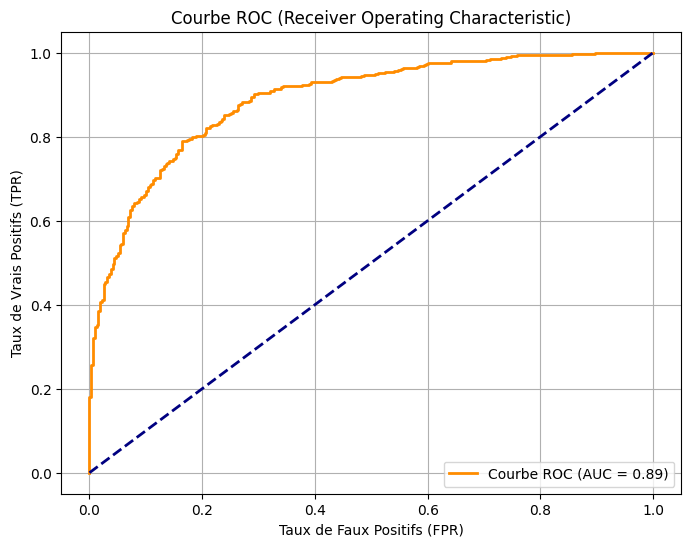

In [236]:
# Calcul et affichage de la courbe ROC et de l'AUC
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC (Receiver Operating Characteristic)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Visualisation des relations entre les caractéristiques d'entraînement et la variable cible

In [237]:
# Séparons les colonnes numériques et catégorielles de 'x'

numerical_cols = x.select_dtypes(include=np.number).columns.tolist()
categorical_cols = x.select_dtypes(include='object').columns.tolist()

# Exclure 'loan_id' des colonnes numériques car c'est un identifiant
if 'loan_id' in numerical_cols:
    numerical_cols.remove('loan_id')

print("Colonnes numériques :", numerical_cols)
print("Colonnes catégorielles :", categorical_cols)

Colonnes numériques : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Colonnes catégorielles : ['education', 'self_employed']


### Relations des caractéristiques numériques avec `loan_status` (cible)

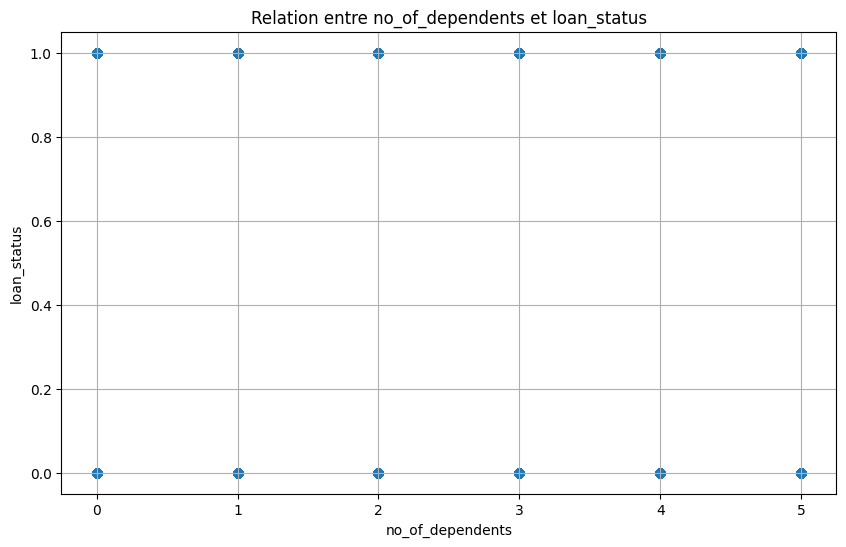

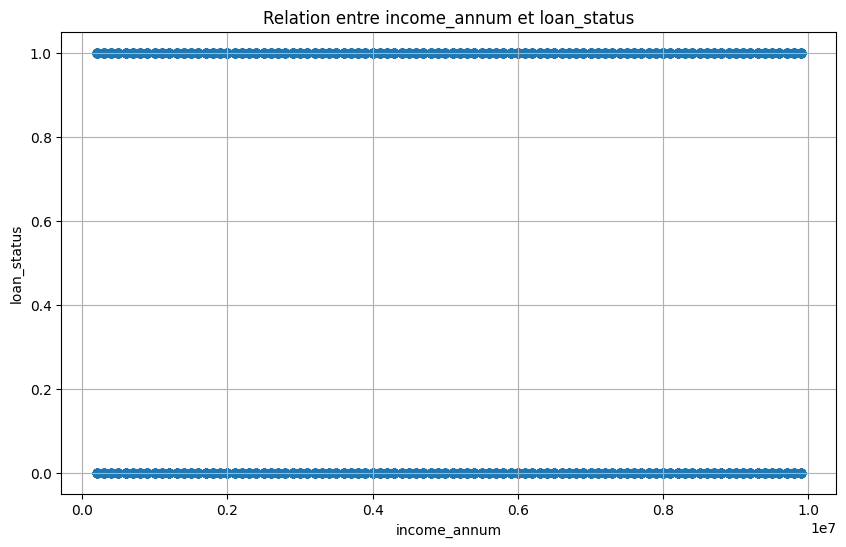

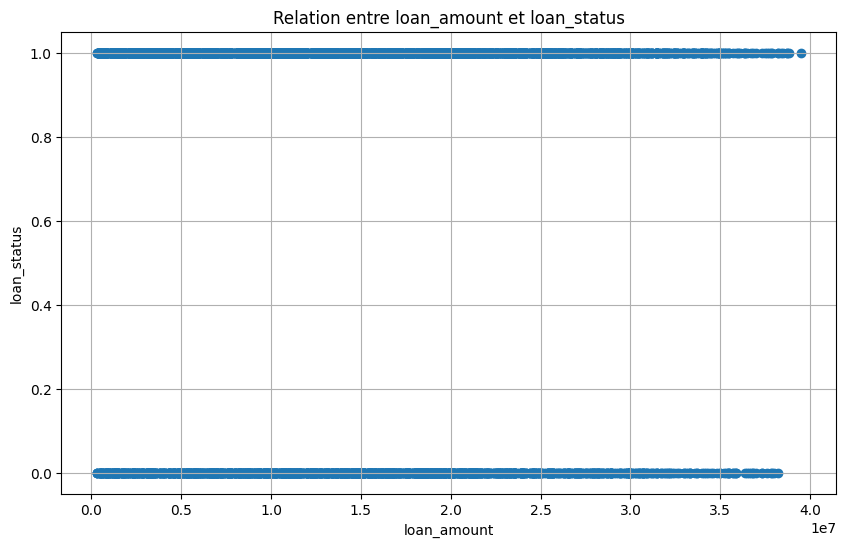

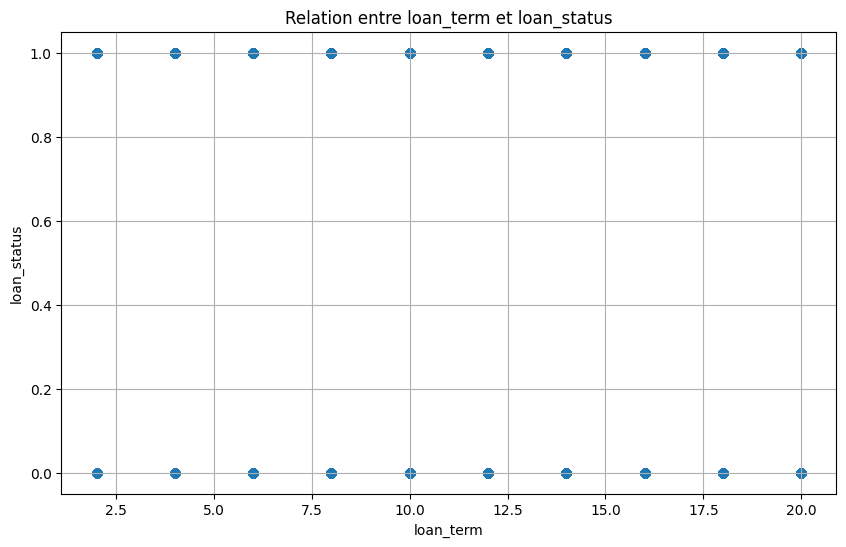

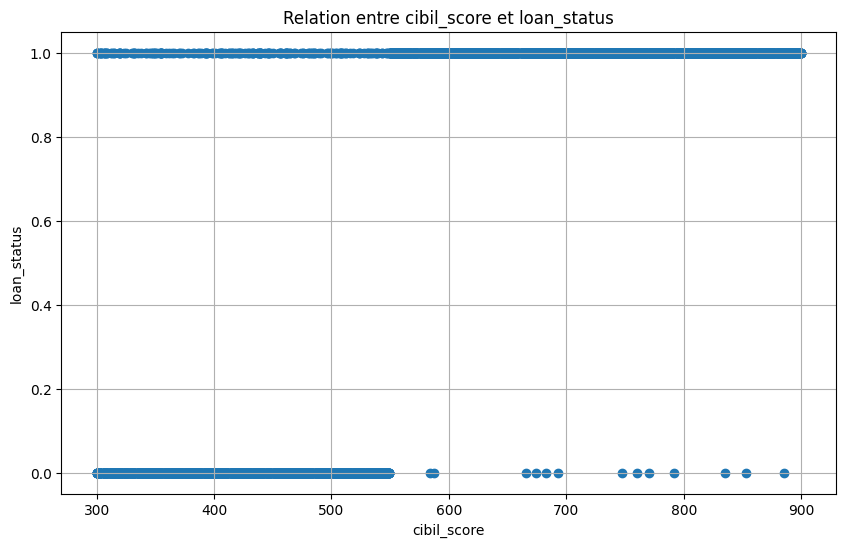

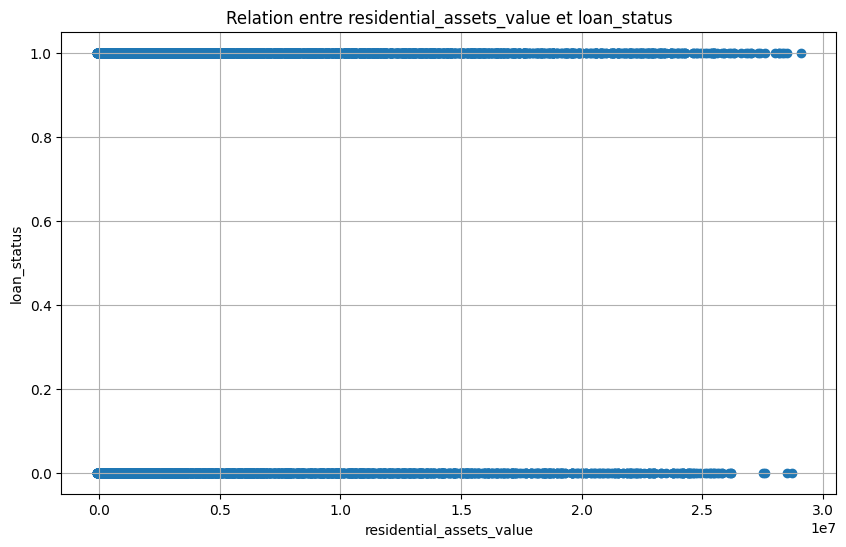

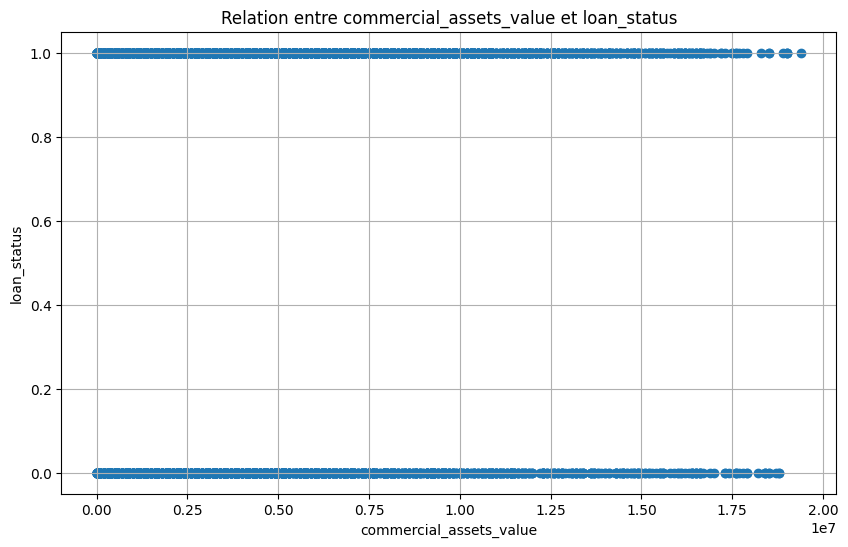

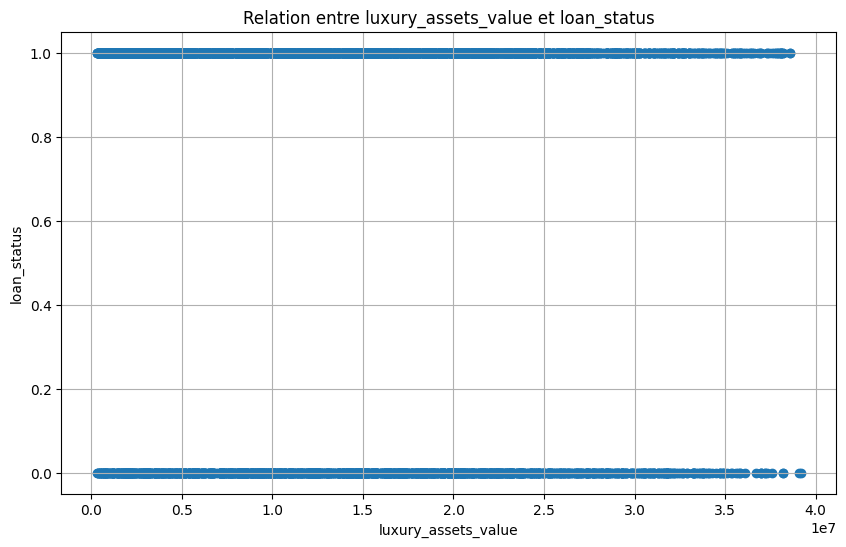

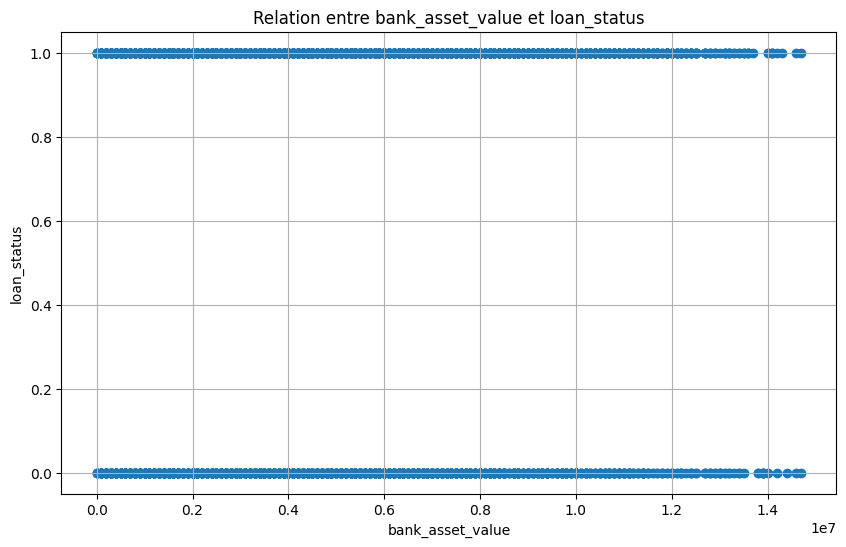

In [238]:
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    plt.scatter(x[col], y)
    plt.xlabel(col)
    plt.ylabel('loan_status')
    plt.title(f'Relation entre {col} et loan_status')
    plt.grid(True)
    plt.show()